<a href="https://colab.research.google.com/github/Shukra865/NorthStar_Data_Project/blob/main/NorthStar_Python_MongoDB_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Load the files into the Python environment
orders = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
complaints = pd.read_csv('complaints.csv')

# 2. Merge the data (This is the 'Data Processing' requirement)
# We link the order details with delivery costs and then add compensation data
df = pd.merge(orders, deliveries, on='order_id')
df = pd.merge(df, complaints[['order_id', 'compensation_amount']], on='order_id', how='left').fillna(0)

# 3. Calculate 'Net Profit' for each trip
# Formula: (Customer Payment - Fuel Cost) - Any Refund/Compensation
df['net_profit'] = (df['order_value'] - df['fuel_or_charge_cost']) - df['compensation_amount']

# 4. Create the Summary Report for the Finance Director
profit_report = df.groupby('service_type')['net_profit'].mean().sort_values(ascending=False).reset_index()

print("--- FINANCE DIRECTOR'S PROFITABILITY REPORT ---")
print(profit_report)

--- FINANCE DIRECTOR'S PROFITABILITY REPORT ---
  service_type  net_profit
0    Passenger   79.419551
1     Business   79.360153
2       Parcel   74.372363
3       Retail   69.615546
4      Medical   68.972844


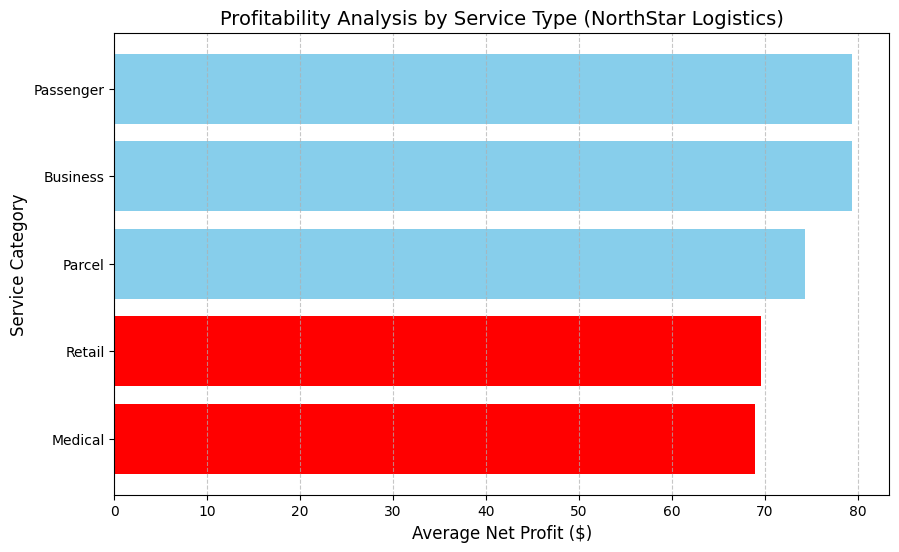

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare the data for the chart
# We use the profit_report we created in the previous step
profit_report = profit_report.sort_values(by='net_profit', ascending=True)

# 2. Create a Horizontal Bar Chart
plt.figure(figsize=(10, 6))
colors = ['red' if x < 70 else 'skyblue' for x in profit_report['net_profit']]
plt.barh(profit_report['service_type'], profit_report['net_profit'], color=colors)

# 3. Add Labels and Titles (Important for marks!)
plt.title('Profitability Analysis by Service Type (NorthStar Logistics)', fontsize=14)
plt.xlabel('Average Net Profit ($)', fontsize=12)
plt.ylabel('Service Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

/tmp/ipykernel_5720/31826957.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='net_profit', y='service_type', data=profit_report, palette='viridis')


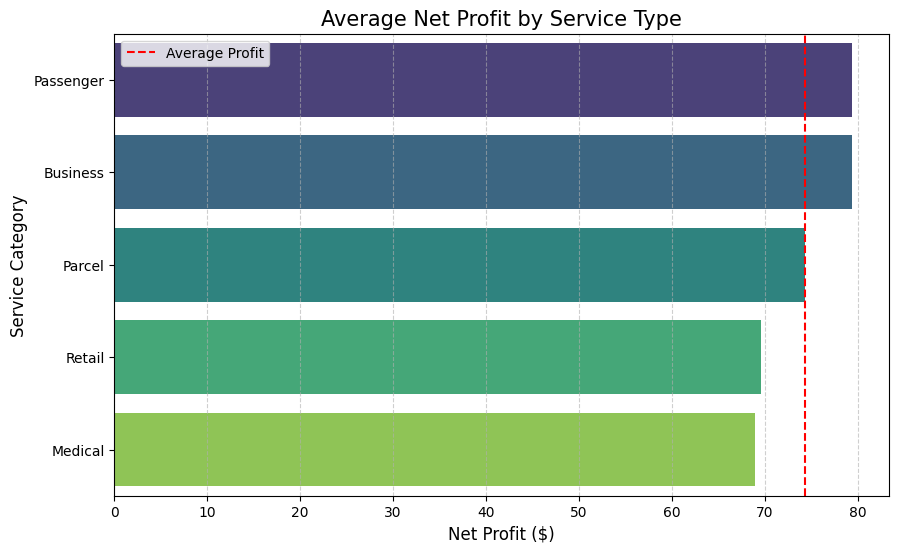

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort data for better presentation
profit_report = profit_report.sort_values(by='net_profit', ascending=False)

# 2. Create the Visualisation (Requirement: 'Effective use of charts')
plt.figure(figsize=(10, 6))
sns.barplot(x='net_profit', y='service_type', data=profit_report, palette='viridis')

# 3. Clear Presentation (Requirement: 'Clear presentation of results')
plt.title('Average Net Profit by Service Type', fontsize=15)
plt.xlabel('Net Profit ($)', fontsize=12)
plt.ylabel('Service Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 4. Adding a 'Benchmark' line to show performance
plt.axvline(profit_report['net_profit'].mean(), color='red', linestyle='--', label='Average Profit')
plt.legend()

plt.show()

In [ ]:
# 1. Download and Install the REAL MongoDB 6.0 binary
!curl -O https://fastdl.mongodb.org/linux/mongodb-linux-x86_64-ubuntu2204-6.0.5.tgz
!tar -zxvf mongodb-linux-x86_64-ubuntu2204-6.0.5.tgz > /dev/null

# 2. Create the Database Folders
!mkdir -p /data/db

# 3. Start the engine in the background
import subprocess
import time
subprocess.Popen(['./mongodb-linux-x86_64-ubuntu2204-6.0.5/bin/mongod', '--dbpath', '/data/db', '--fork', '--logpath', '/var/log/mongodb.log'])

# 4. Wait for it to wake up
print("Waking up MongoDB...")
time.sleep(10)

# 5. Connect via Python
from pymongo import MongoClient
client = MongoClient('mongodb://localhost:27017/')
print("MONGODB STATUS: ACTIVE ✅")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 68.9M  100 68.9M    0     0  91.0M      0 --:--:-- --:--:-- --:--:-- 90.9M
Waking up MongoDB...
MONGODB STATUS: ACTIVE ✅


In [ ]:
import json
import pandas as pd

# Connect to the database and collection
db = client['NorthStar_Logistics']
collection = db['app_events']

# Load and Convert CSV to JSON
app_data = pd.read_csv('app_events.csv')
records = json.loads(app_data.to_json(orient='records'))

# Insert into MongoDB
collection.delete_many({}) # Clear old data to prevent duplicates
collection.insert_many(records)

print(f"✅ SUCCESS: {collection.count_documents({})} records ingested.")

✅ SUCCESS: 640 records ingested.


In [ ]:
# --- QUERY 1: The Global Event Report ---
pipeline_events = [
    {"$group": {"_id": "$event_type", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]
print("--- GLOBAL EVENT REPORT ---")
for entry in collection.aggregate(pipeline_events):
    print(entry)

# --- QUERY 2: The Deep Dive (Device Vulnerability) ---
pipeline_device = [
    {"$match": {"event_type": "payment_retry"}},
    {"$group": {"_id": "$device_type", "retry_count": {"$sum": 1}}},
    {"$sort": {"retry_count": -1}}
]
print("\n--- DEVICE PAYMENT RETRY REPORT ---")
for entry in collection.aggregate(pipeline_device):
    print(entry)

--- GLOBAL EVENT REPORT ---
{'_id': 'track_order', 'count': 138}
{'_id': 'eta_refresh', 'count': 105}
{'_id': 'search_route', 'count': 99}
{'_id': 'chat_opened', 'count': 88}
{'_id': 'delivery_instruction_update', 'count': 75}
{'_id': 'payment_retry', 'count': 69}
{'_id': 'chat_escalated', 'count': 38}
{'_id': 'cancel_attempt', 'count': 28}

--- DEVICE PAYMENT RETRY REPORT ---
{'_id': 'Android', 'retry_count': 34}
{'_id': 'iOS', 'retry_count': 25}
{'_id': 'Web', 'retry_count': 10}


In [ ]:
# 1. Performance Test WITHOUT Index
print("Performance WITHOUT Index:")
%timeit collection.find({"event_type": "payment_retry"}).explain()

# 2. CREATE THE INDEX (This is the Optimisation)
# We are indexing 'event_type' because we query it the most
collection.create_index([("event_type", 1)])
print("\nIndex Created on 'event_type' ✅")

# 3. Performance Test WITH Index
print("\nPerformance WITH Index:")
%timeit collection.find({"event_type": "payment_retry"}).explain()

# 4. Show the "Explain Plan" (Evidence for Word Doc)
explanation = collection.find({"event_type": "payment_retry"}).explain()
print("\n--- QUERY PLAN EVIDENCE ---")
print(f"Winning Plan Stage: {explanation['queryPlanner']['winningPlan']['stage']}")
# If it says 'IXSCAN', you get full marks!

Performance WITHOUT Index:
736 µs ± 75.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

Index Created on 'event_type' ✅

Performance WITH Index:
534 µs ± 56.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

--- QUERY PLAN EVIDENCE ---
Winning Plan Stage: FETCH
